# frame-map

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [26]:
coord_src = [[750, 750], [870, 780], [1435, 375], [1550, 400]]
# UL, DL, UR, DR
coord_map = [[280, 600], [280, 710], [1520, 600], [1520, 710]]

In [27]:
import cv2
import numpy as np

# Load images
img1 = cv2.imread('src_out/frame_0.jpg')
img2 = cv2.imread('map.png')

# Find the homography matrix using RANSAC
H, mask = cv2.findHomography(np.array(coord_src), np.array(coord_map), cv2.RANSAC, 5.0)

# Use the homography matrix to warp img1 to match img2
height, width, _ = img2.shape
img1_aligned = cv2.warpPerspective(img1, H, (width, height))

# Save the output images
cv2.imwrite('aligned_image.jpg', img1_aligned)


True

In [28]:
H

array([[ 6.33350857e-01, -2.44908326e+00,  1.70048531e+03],
       [ 7.71207920e-01,  1.56415416e+00, -1.02576582e+03],
       [ 7.22875171e-06,  2.72228455e-04,  1.00000000e+00]])

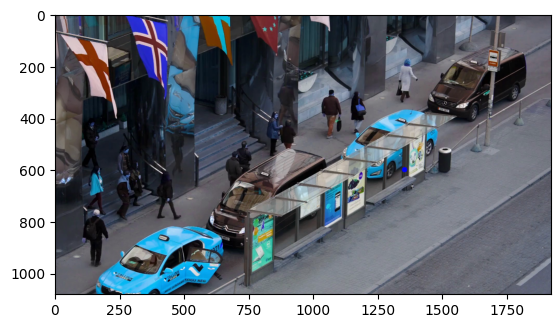

In [31]:
# Define the point coordinates
src = cv2.imread('src_out/frame_0.jpg')
points = (1350, 600)

# Draw a red point at the specified coordinates
color = (0, 0, 255)  # Red color in BGR
thickness = -1  # Thickness -1 will fill the circle
radius = 10
cv2.circle(src, points, radius, color, thickness)
plt.imshow(src)

In [29]:
import cv2
import numpy as np

# Assuming you have the homography matrix 'H' and source coordinates 'src_pts' in the source image
# Define the source points as a numpy array
src_pts = np.array([[1350, 600]], dtype=np.float32)

# Reshape the source points to be a 3D array
src_pts = src_pts.reshape(-1, 1, 2)

# Use perspectiveTransform to find the coordinates of the corresponding points in the target image
dst_pts = cv2.perspectiveTransform(src_pts, H)

# Print the transformed coordinates in the target image
for point in dst_pts:
    x, y = point[0]
    print("Transformed Point: ({}, {})".format(x, y))

Transformed Point: (925.8058471679688, 813.1111450195312)


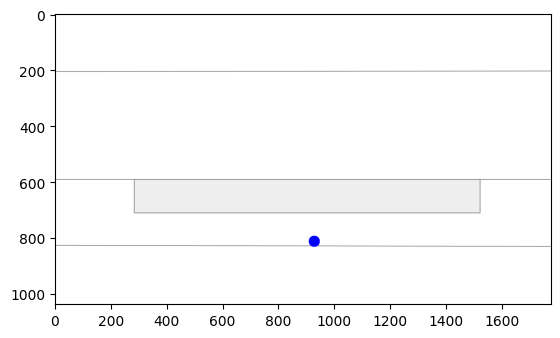

In [30]:
# Define the point coordinates
map = cv2.imread('map.png')
points = (926, 813)

# Draw a red point at the specified coordinates
color = (0, 0, 255)  # Red color in BGR
thickness = -1  # Thickness -1 will fill the circle
radius = 20
cv2.circle(map, points, radius, color, thickness)
plt.imshow(map)

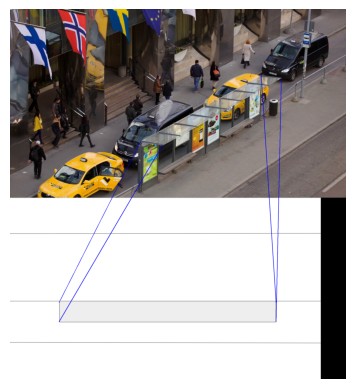

In [37]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the two images
image1 = cv2.imread('src_out/frame_0.jpg')
image2 = cv2.imread('map.png')

# Define coordinates for points in image 1 and image 2
points_image1 = np.array(coord_src)
points_image2 = np.array(coord_map)

# Create an image with the dimensions to accommodate both images
max_width = max(image1.shape[1], image2.shape[1])
total_height = image1.shape[0] + image2.shape[0]
image_combined = np.zeros((total_height, max_width, 3), dtype=np.uint8)

# Place the first image at the top of the combined image
image_combined[:image1.shape[0], :image1.shape[1]] = image1

# Place the second image below the first image
image_combined[image1.shape[0]:, :image2.shape[1]] = image2

# Draw lines between corresponding points in the two images
for i in range(4):
    pt1 = (points_image1[i][0], points_image1[i][1])
    pt2 = (points_image2[i][0], points_image2[i][1] + image1.shape[0])  # Adjust y-coordinate for the second image
    cv2.line(image_combined, pt1, pt2, (255, 0, 0), 2)

# Display the combined image with lines connecting the points
plt.imshow(cv2.cvtColor(image_combined, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Turn off axis
plt.show()

# video

In [38]:
import os
import shutil
import cv2

def convert_video_to_images(input_video, output_folder):
    # Create output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    else:
        shutil.rmtree(output_folder)
        os.makedirs(output_folder)

    # Open the video file
    video_capture = cv2.VideoCapture(input_video)
    success, frame = video_capture.read()
    count = 0

    # Read each frame and save it as an image
    while success: # and count < 1000:
        image_path = os.path.join(output_folder, f"frame_{count:d}.jpg")  # Adjust the format as per your requirement
        cv2.imwrite(image_path, frame)  # Save the frame as an image
        success, frame = video_capture.read()  # Read next frame
        count += 1

    # Release the video capture object
    video_capture.release()
    return count

count = convert_video_to_images('uid_vid_00000.mp4', 'src_out')

In [39]:
idx = 426 #count - 1

In [2]:
import json

# Path to your JSON file
json_file_path = 'uid_vid_00000.mp4.json'

# Function to read data from a JSON file, convert string values to integers, and sort based on the first two dimensions
def read_and_sort_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)

    # Convert string values to integers and sort based on the first two dimensions
    tmp = {}
    for key, value in data.items():
        converted_value = {int(k): [int(item) for item in v] for k, v in value.items()}
        sorted_value = dict(sorted(converted_value.items(), key=lambda x: x[0]))
        tmp[int(key)] = sorted_value

    sorted_data = dict(sorted(tmp.items(), key=lambda x: x[0]))
    return sorted_data

# Read, convert, and sort data from the JSON file
sorted_json_data = read_and_sort_json_file(json_file_path)

In [3]:
first_frame_num = next(iter(sorted_json_data.keys()))

In [55]:
import json
import numpy as np

def trans(src_pts, H):
    #src_pts = [1350, 600]
    arr = np.array(src_pts, dtype=np.float32)
    arr_tmp = arr.reshape(-1, 1, 2)
    dst_pts = cv2.perspectiveTransform(arr_tmp, H)
    for point in dst_pts:
        x, y = point[0]
        return int(x), int(y)

# Sample nested dictionary
data = {}
# Calculate the average of specific values in the list and convert them to integers
for key, value in sorted_json_data.items():
    tmp = {}
    for inner_key, inner_value in value.items():
        #center
        #pts_src = [int(inner_value[0] + inner_value[2]/2), int(inner_value[1] + inner_value[3]/2)]
        #bottom_mid
        pts_src = [int(inner_value[0] + inner_value[2]/2), int(inner_value[1])]
        pts_map = trans(pts_src, H)
        tmp[inner_key] = pts_map
    data[key] = tmp

In [56]:
data

{0: {1: (-69, 628),
  13: (928, -196),
  14: (1017, -217),
  16: (739, -20),
  17: (679, 46),
  18: (841, 10),
  20: (968, -150),
  22: (723, -266),
  23: (-36, 222),
  24: (875, -74),
  25: (1529, 56),
  26: (315, 12),
  27: (555, -30),
  29: (333, 105),
  30: (441, 81),
  33: (436, 215),
  34: (1567, 42),
  35: (2025, 276),
  36: (1583, 306),
  37: (1531, 232),
  38: (1187, 195),
  39: (1136, 273),
  41: (740, 287),
  42: (849, 262)},
 5: {1: (-69, 628),
  4: (-83, 83),
  13: (940, -194),
  14: (1012, -214),
  16: (742, -16),
  17: (660, 60),
  18: (871, 8),
  20: (970, -148),
  22: (724, -243),
  23: (-18, 222),
  24: (835, -45),
  25: (1532, 74),
  26: (298, 31),
  27: (557, -19),
  29: (315, 131),
  30: (452, 93),
  33: (429, 230),
  34: (1571, 47),
  35: (2060, 265),
  36: (1596, 314),
  37: (1567, 217),
  38: (1215, 193),
  39: (1174, 262),
  41: (773, 287),
  42: (883, 262)},
 10: {1: (-71, 626),
  4: (10, 35),
  13: (932, -190),
  14: (1010, -212),
  16: (727, -4),
  17: (635,

In [57]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import shutil

# Function to draw line tracking for each object
def draw_tracking(frame, object_data, prev_object_data):
    for obj_id, (x, y) in object_data.items():
        if obj_id in prev_object_data:
            prev_x, prev_y = prev_object_data[obj_id]
            cv2.line(frame, (prev_x, prev_y), (x, y), (0, 255, 0), 2)  # Draw a line between previous and current position
        cv2.circle(frame, (x, y), 5, (0, 0, 255), -1)  # Draw a circle at the current position
    return frame

# Sample object data for each frame (object ID with (x, y) coordinate)
object_data_frame1 = {1: (50, 50), 2: (100, 100)}
object_data_frame2 = {1: (60, 60), 2: (110, 110)}
# Add more object data for subsequent frames as needed

# Initialize previous object data
prev_object_data = {}

import shutil
folder = 'temp_out'
if not os.path.exists(folder):
    os.makedirs(folder)
else:
    shutil.rmtree(folder)
    os.makedirs(folder)

for frame_number, object_data in data.items():
    if int(frame_number) > idx:
        break
    #print(f"Frame {frame_number}:")
    num = int(frame_number)
    #frame = cv2.imread(f'src_out/frame_{num}.jpg')  # Load the frame for src_img
    frame = cv2.imread('map.png')
    if num == first_frame_num:
        prev_object_data = object_data
        current_object_data = object_data
    else:
        prev_object_data = current_object_data
        current_object_data = object_data

    # Draw line tracking for each object
    frame_with_tracking = draw_tracking(frame, current_object_data, prev_object_data)

    # save image for GIF
    fig = plt.figure(figsize=(15, 7))
    plt.imshow(frame_with_tracking)
    plt.axis('off')
    fig.savefig(f"temp_out/frame_{frame_number}.jpg")
    plt.close()

In [65]:
frame = cv2.imread('map.png')
fig = plt.figure(figsize=(15, 7))
plt.imshow(frame)
plt.axis('off')
fig.savefig('out_back')
plt.close()

In [66]:
import os
import shutil

# Source folder to be copied
source_folder = 'temp_out'

# Destination folder for the copy
destination_folder = 'temp_out2'
if not os.path.exists(destination_folder):
    #os.makedirs(destination_folder)
    pass
else:
    shutil.rmtree(destination_folder)
    #os.makedirs(destination_folder)

# Copy the folder and its contents
shutil.copytree(source_folder, destination_folder)

print(f'Folder copied from {source_folder} to {destination_folder}')

# Path to the sample image
map = 'out_back.png'

# Generate filenames and save images
for i in range(427):  # Range from 0 to 426 inclusive
    new_filename = f'frame_{i}.jpg'
    new_image_path = os.path.join(destination_folder, new_filename)
    
    if os.path.exists(new_image_path):
        #print(f'The file {new_image_path} exists in the folder.')
        continue
    else:
        #print(f'The file {new_image_path} does not exist in the folder.')
        shutil.copy2(map, new_image_path)
        #frame = cv2.imread('map.png')
        #fig = plt.figure(figsize=(15, 7))
        #plt.imshow(frame)
        #plt.axis('off')
        #fig.savefig(new_image_path)
        #plt.close()

Folder copied from temp_out to temp_out2


In [67]:
import glob
import os
from PIL import Image
import re

def extract_frame_number(file_name):
    return int(re.search(r'\d+', file_name).group())

def create_gif_from_images(save_path : str, image_path : str, ext : str) -> None:
    ''' creates a GIF from a folder of images
        Inputs:
            save_path - path to save GIF
            image_path - path where images are located
            ext - extension of the images
        Outputs:
            None
    '''
    print('start to create GIF')
    # Sort the file names based on the extracted integer value
    image_paths = sorted([f for f in os.listdir(image_path) if f.endswith('.jpg') or f.endswith('.png')], key=extract_frame_number)
    pil_images = [Image.open(os.path.join(image_path, im_path)) for im_path in image_paths]
    #print(image_paths)

    pil_images[0].save(save_path, format='GIF', append_images=pil_images,
                       save_all=True, duration=50, loop=0)
  
create_gif_from_images('tracking_outdoor.gif', 'temp_out2', '.png')

start to create GIF
